# Garbage Classification Tiny CNN Int8 Model (OpenMV-friendly)

This notebook is the **generic** part of the pipeline:
- Download or load a dataset
- Train a tiny grayscale CNN classifier (NPU-friendly ops)
- Export a fully-integer **int8** `.tflite`
- Sanity-check the exported model on desktop with `tf.lite.Interpreter`

You can then choose an accelerator-specific notebook:
- `CustomObjects_OpenMV_AE3_EthosU55.ipynb` (Vela / Ethos-U55)
- `CustomObjects_OpenMV_N6_NeuralART.ipynb` (ST Edge AI / Neural-ART)


In [9]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math # Added for ceil function

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


### Exploring Hyperparameters for Improved Accuracy

To fine-tune the model and potentially improve accuracy, we can experiment with different hyperparameters. Below, you can set values for the learning rate, warm-up schedule, and callback patience. After adjusting these, you'll need to re-run the relevant cells to see their effect on training.

In [3]:
OVERSAMPLE_FACTOR = 2 # How many times to duplicate minority class samples
MINORITY_CLASS_WEIGHT_THRESHOLD = 1.0 # Classes with weight > this will be oversampled

# --- Tunable Hyperparameters ---
# Learning Rate for Adam optimizer
NEW_LEARNING_RATE = 3e-4

# Warm-up schedule parameters
WARMUP_EPOCHS = 5
INITIAL_LR_WARMUP = 1e-6
TARGET_LR_WARMUP = NEW_LEARNING_RATE # Should typically match NEW_LEARNING_RATE

# ReduceLROnPlateau callback parameters
LR_REDUCE_FACTOR = 0.5
LR_REDUCE_PATIENCE = 5
LR_REDUCE_MIN_LR = 1e-5

# EarlyStopping callback parameters
ES_PATIENCE = 12

print(f"Set NEW_LEARNING_RATE: {NEW_LEARNING_RATE}")
print(f"Set WARMUP_EPOCHS: {WARMUP_EPOCHS}, INITIAL_LR_WARMUP: {INITIAL_LR_WARMUP}, TARGET_LR_WARMUP: {TARGET_LR_WARMUP}")
print(f"Set LR_REDUCE_FACTOR: {LR_REDUCE_FACTOR}, LR_REDUCE_PATIENCE: {LR_REDUCE_PATIENCE}, LR_REDUCE_MIN_LR: {LR_REDUCE_MIN_LR}")
print(f"Set ES_PATIENCE: {ES_PATIENCE}")

Set NEW_LEARNING_RATE: 0.0003
Set WARMUP_EPOCHS: 5, INITIAL_LR_WARMUP: 1e-06, TARGET_LR_WARMUP: 0.0003
Set LR_REDUCE_FACTOR: 0.5, LR_REDUCE_PATIENCE: 5, LR_REDUCE_MIN_LR: 1e-05
Set ES_PATIENCE: 12


## 1) Dataset

Two options:

### Option A: local folder dataset (recommended for your own custom objects)
```
data/
  train/
    mug/
    keys/
    remote/
  val/
    mug/
    keys/
    remote/
```

### Option B: KaggleHub download (good for a quick public dataset)
Example:
```
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
```

For Option B we do a stratified train/val split on the fly.


In [4]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold # NEW: Import for k-fold
from sklearn.utils import class_weight # Import for class weight calculation

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)

USE_KAGGLEHUB = True
KAGGLE_DATASET = "asdasdasasdas/garbage-classification"
FORCE_CLASS_ROOT = None  # set to a path string if auto-detection picks the wrong folder

DATA_DIR = Path('data')
IMG_SZ = 96
BATCH = 64
VAL_FRAC = 0.3
K_FOLDS = 5 # NEW: Number of folds for cross-validation

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def _has_images(p: Path) -> bool:
    for f in p.iterdir():
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            return True
    return False


def find_class_root(root: Path, max_depth: int = 6) -> Path:
    """Find a directory whose immediate subfolders look like class folders."""
    root = root.resolve()
    best = None
    best_score = (-1, -1)

    def depth(p: Path) -> int:
        try:
            return len(p.relative_to(root).parts)
        except Exception:
            return 999

    dirs = [root]
    for p in root.rglob('*'):
        if p.is_dir() and depth(p) <= max_depth:
            dirs.append(p)

    for d in dirs:
        subdirs = [s for s in d.iterdir() if s.is_dir()]
        if len(subdirs) < 2:
            continue
        class_dirs = [s for s in subdirs if _has_images(s)]
        if len(class_dirs) < 2:
            continue

        img_count = 0
        for c in class_dirs:
            img_count += sum(1 for f in c.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXTS)
        score = (len(class_dirs), img_count)
        if score > best_score:
            best_score = score
            best = d

    if best is None:
        raise RuntimeError(f"Could not find class folders under: {root}")
    return best


def index_from_class_root(class_root: Path):
    class_dirs = [d for d in class_root.iterdir() if d.is_dir() and _has_images(d)]
    class_names = sorted([d.name for d in class_dirs])
    name_to_id = {n: i for i, n in enumerate(class_names)}

    items = []
    for cname in class_names:
        cdir = class_root / cname
        for p in sorted(cdir.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                items.append((str(p), name_to_id[cname]))
    return items, class_names


def split_items(items, val_frac=0.2):
    from collections import defaultdict

    by_cls = defaultdict(list)
    for p, y in items:
        by_cls[int(y)].append(p)

    train, val = [], []
    rng = np.random.default_rng(0)
    for y, paths in by_cls.items():
        paths = list(paths)
        rng.shuffle(paths)
        n_val = int(len(paths) * val_frac)
        val_paths = paths[:n_val]
        train_paths = paths[n_val:]
        train.extend([(p, y) for p in train_paths])
        val.extend([(p, y) for p in val_paths])

    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


def load_image_label(path, y):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SZ, IMG_SZ)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.float32) / 255.0
    return img, tf.cast(y, tf.int32)


def ds_from_items(items, shuffle=False):
    paths = [p for p, _ in items]
    labels = [int(y) for _, y in items]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(4096, len(paths)), seed=0)
    ds = ds.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds


train_dir = DATA_DIR / 'train'
val_dir = DATA_DIR / 'val'

# NOTE: This branch of code assumes pre-split folders and does not prepare for k-fold.
# For k-fold, it would need to collect all images and labels from both train_dir and val_dir.
if (not USE_KAGGLEHUB) and train_dir.exists() and val_dir.exists():
    print('Using folder dataset:', train_dir, val_dir)
    # This part would need significant modification for K-fold if USE_KAGGLEHUB is False.
    # For now, assuming USE_KAGGLEHUB is True as per notebook execution.
    raise NotImplementedError("K-fold not implemented for local folder dataset yet.")
else:
    import kagglehub
    path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print('KaggleHub dataset path:', path)

    class_root = Path(FORCE_CLASS_ROOT) if FORCE_CLASS_ROOT else find_class_root(path)
    print('Class root:', class_root)

    items, class_names = index_from_class_root(class_root)

    # Split into initial train/val sets
    initial_train_items, val_items = split_items(items, val_frac=VAL_FRAC)

    # Calculate class weights for the initial training data to identify minority classes
    initial_train_labels = [label for _, label in initial_train_items]
    class_weights_for_oversampling_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(initial_train_labels),
        y=initial_train_labels
    )
    class_weights_for_oversampling_dict = dict(enumerate(class_weights_for_oversampling_array))

    print("Initial Train Class Weights for Oversampling:", class_weights_for_oversampling_dict)

    # Apply simple oversampling for minority classes in the training set
    oversampled_train_items = []
    for p, y in initial_train_items:
        oversampled_train_items.append((p, y)) # Always add the original sample
        # If the class weight is above the threshold, oversample it
        # OVERSAMPLE_FACTOR and MINORITY_CLASS_WEIGHT_THRESHOLD are defined in cell 'ffe20b2d'
        if class_weights_for_oversampling_dict.get(y, 1.0) > MINORITY_CLASS_WEIGHT_THRESHOLD:
            for _ in range(OVERSAMPLE_FACTOR - 1): # Duplicate (OVERSAMPLE_FACTOR - 1) times
                oversampled_train_items.append((p, y))

    np.random.shuffle(oversampled_train_items)
    train_items = oversampled_train_items
    print(f"Oversampled training items from {len(initial_train_items)} to {len(train_items)}")

    print('Train images:', len(train_items), 'Val images:', len(val_items))
    train_ds = ds_from_items(train_items, shuffle=True)
    val_ds = ds_from_items(val_items, shuffle=False)


NUM_CLASSES = len(class_names)
print('NUM_CLASSES:', NUM_CLASSES)

TensorFlow: 2.20.0
Using Colab cache for faster access to the 'garbage-classification' dataset.
KaggleHub dataset path: /kaggle/input/garbage-classification
Class root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Initial Train Class Weights for Oversampling: {0: np.float64(1.0429917550058894), 1: np.float64(0.8409306742640076), 2: np.float64(1.0284552845528456), 3: np.float64(0.7095352564102564), 4: np.float64(0.8732741617357002), 5: np.float64(3.0746527777777777)}
Oversampled training items from 1771 to 2437
Train images: 2437 Val images: 756
NUM_CLASSES: 6


In [ ]:
from tensorflow.keras import layers

augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
print('Train images:', len(train_items), 'Val images:', len(val_items))

Train images: 2437 Val images: 756


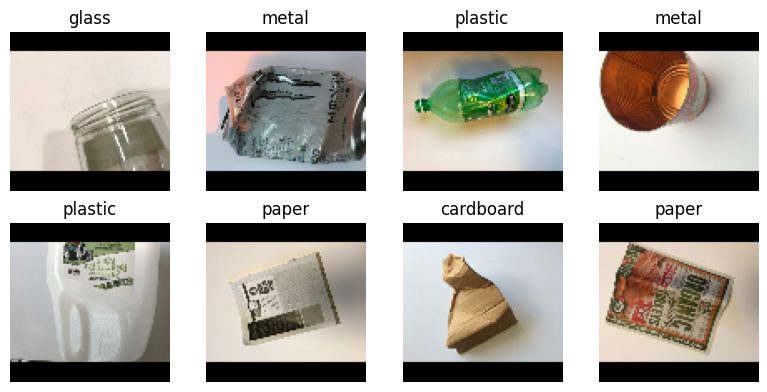

In [5]:
# Visualize a small batch
x, y = next(iter(train_ds))
plt.figure(figsize=(8, 4))
for i in range(min(8, x.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x[i], vmin=0, vmax=1)
    plt.title(class_names[int(y[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 2) Tiny, NPU-friendly CNN

Design constraints for edge/NPU:
- Prefer `Conv2D`, `DepthwiseConv2D`, `Add`, `ReLU`, `GlobalAveragePooling`
- Avoid big fully-connected layers
- Keep channels modest


In [6]:
from tensorflow.keras import layers, models, regularizers

def build_tiny_ds_cnn(input_shape=(96, 96, 1), num_classes=3):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(24, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name='tiny_ds_cnn')

def conv_bn_relu(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_small_cnn(input_shape=(96, 96, 3), num_classes=6):
    inp = layers.Input(shape=input_shape)
    x = layers.Rescaling(1.0)(inp)

    # momentum=0.9: running stats update 10x faster than the default 0.99,
    # closing the train-vs-eval BN statistics gap that causes noisy validation.
    BN  = lambda: layers.BatchNormalization(momentum=0.9)
    # L2 regularization prevents convolutional weight magnitudes from growing
    # unbounded, which is the primary cause of the catastrophic validation spikes.
    REG = regularizers.l2(1e-4)

    # Block 1
    x = conv_bn_relu(x, 32)
    x = conv_bn_relu(x, 32)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = conv_bn_relu(x, 64)
    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 3 — 128 filters, learn high-level object parts
    x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D()(x)   # → 12x12
    x = layers.Dropout(0.3)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=REG)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='small_cnn')


model = build_small_cnn(input_shape=(IMG_SZ, IMG_SZ, 3), num_classes=NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=NEW_LEARNING_RATE, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 149,030 (582.15 KB)

 Trainable params: 148,390 (579.65 KB)

 Non-trainable params: 640 (2.50 KB)

In [7]:
from sklearn.utils import class_weight

# Extract labels from train_items
train_labels = [label for _, label in train_items]

# Calculate class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to a dictionary for model.fit
class_weights_dict = dict(enumerate(class_weights_array))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(0.7176089517078916), 1: np.float64(1.157169990503324), 2: np.float64(0.7076074332171893), 3: np.float64(0.9763621794871795), 4: np.float64(1.2016765285996056), 5: np.float64(2.115451388888889)}


In [8]:
def linear_warmup_schedule(epoch, lr):

    if epoch < WARMUP_EPOCHS:
        # Linearly increase LR during warm-up
        lr = INITIAL_LR_WARMUP + (TARGET_LR_WARMUP - INITIAL_LR_WARMUP) * (epoch / WARMUP_EPOCHS)
    else:
        # After warm-up, let ReduceLROnPlateau handle the schedule
        # Or you could define a decay schedule here
        pass # Keep the current LR or let other callbacks manage it
    return lr

lr_scheduler_callback = tf.keras.callbacks.LearningRateScheduler(linear_warmup_schedule)

In [10]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=LR_REDUCE_FACTOR,
        patience=LR_REDUCE_PATIENCE,
        min_lr=LR_REDUCE_MIN_LR,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=ES_PATIENCE,
        restore_best_weights=True,
    ),
    lr_scheduler_callback # Add the warm-up LR scheduler
]

num_epochs = 200
STEP_SIZE_TRAIN = math.ceil(len(train_items) / BATCH)
STEP_SIZE_TEST = math.ceil(len(val_items) / BATCH)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=num_epochs,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_steps=STEP_SIZE_TEST,
    callbacks=callbacks,
    shuffle=True,
    batch_size=64,
    verbose=2,
)

Epoch 1/200
39/39 - 40s - 1s/step - accuracy: 0.2072 - loss: 2.6260 - val_accuracy: 0.1627 - val_loss: 1.8418 - learning_rate: 1.0000e-06
Epoch 2/200
39/39 - 9s - 233ms/step - accuracy: 0.2060 - loss: 2.2913 - val_accuracy: 0.1627 - val_loss: 1.9021 - learning_rate: 6.0800e-05
Epoch 3/200
39/39 - 4s - 110ms/step - accuracy: 0.2741 - loss: 1.8547 - val_accuracy: 0.1905 - val_loss: 1.9040 - learning_rate: 1.2060e-04
Epoch 4/200
39/39 - 5s - 134ms/step - accuracy: 0.3213 - loss: 1.6808 - val_accuracy: 0.2156 - val_loss: 1.8495 - learning_rate: 1.8040e-04
Epoch 5/200
39/39 - 4s - 111ms/step - accuracy: 0.3726 - loss: 1.5512 - val_accuracy: 0.2989 - val_loss: 1.8058 - learning_rate: 2.4020e-04
Epoch 6/200
39/39 - 6s - 150ms/step - accuracy: 0.4214 - loss: 1.4480 - val_accuracy: 0.2897 - val_loss: 1.8075 - learning_rate: 2.4020e-04
Epoch 7/200
39/39 - 9s - 223ms/step - accuracy: 0.4530 - loss: 1.4051 - val_accuracy: 0.2989 - val_loss: 1.7463 - learning_rate: 2.4020e-04
Epoch 8/200
39/39 - 5s

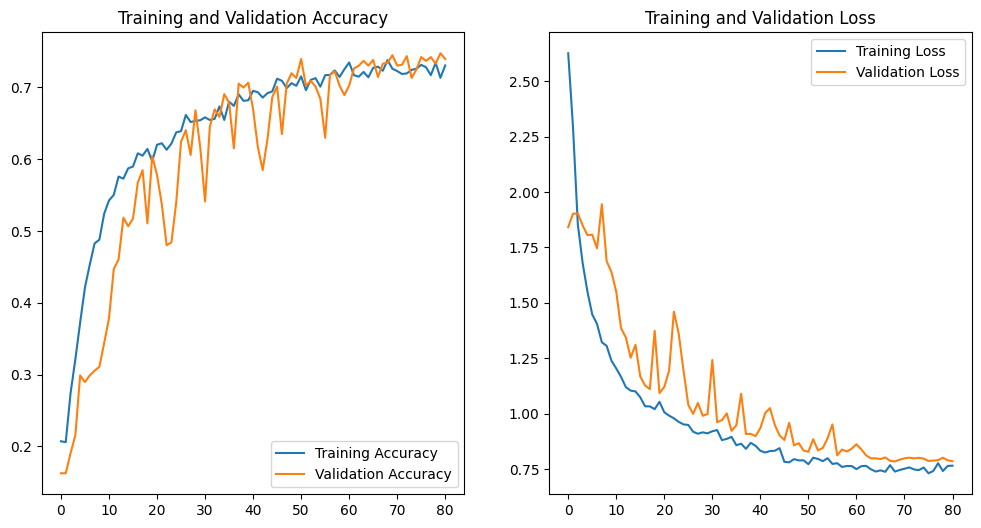

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

From the plots above, we can observe the following:

*   **Training Accuracy and Loss**: The training accuracy generally increases, and the training loss generally decreases over epochs, which is expected as the model learns from the training data.
*   **Validation Accuracy and Loss**: The validation accuracy also shows an increasing trend, and validation loss decreases, indicating that the model is indeed learning and generalizing to unseen data. There might be some fluctuations, but the overall trend suggests learning.

Since both training and validation metrics are improving, the model is learning. However, the gap between training and validation accuracy/loss can indicate overfitting if the training performance significantly outperforms validation performance.

In [12]:
from collections import Counter

print(Counter([y for _, y in train_items]))
print(Counter([y for _, y in val_items]))

y_true = []
y_pred = []

for xb, yb in val_ds:
    pred = model.predict(xb, verbose=0).argmax(axis=1)
    y_true.extend(yb.numpy())
    y_pred.extend(pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES)
print(cm.numpy())

Counter({2: 574, 0: 566, 3: 416, 1: 351, 4: 338, 5: 192})
Counter({3: 178, 1: 150, 4: 144, 2: 123, 0: 120, 5: 41})
[[105   0   0  10   4   1]
 [  3 105   8   6  22   6]
 [  2  20  79   5   8   9]
 [  2   4   6 147   5  14]
 [  2  20  10   9  97   6]
 [  5   6   2   6   0  22]]


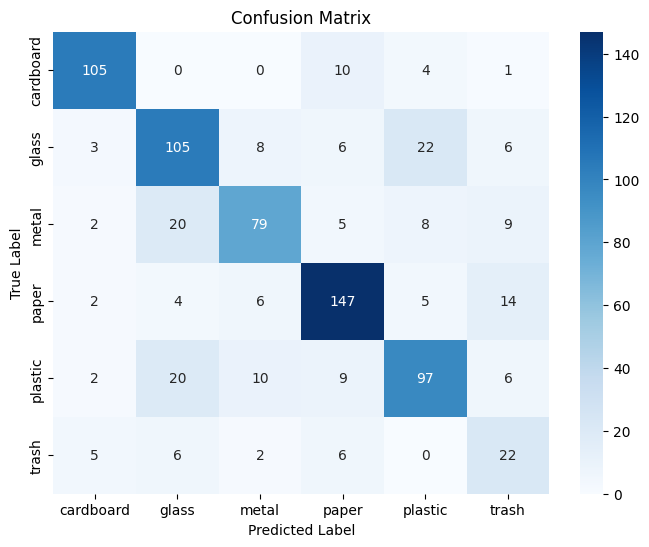

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm.numpy(), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 1.1) K-fold Cross-Validation Setup

Now that the dataset is loaded, we'll set up a K-fold cross-validation loop. This ensures a more robust evaluation of the model's performance by training and validating on different subsets of the data.

In [ ]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

fold_histories = []

print(f"Starting {K_FOLDS}-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")

    fold_train_paths, fold_train_labels = all_paths[train_idx], all_labels[train_idx]
    fold_val_paths, fold_val_labels = all_paths[val_idx], all_labels[val_idx]

    # Create datasets for the current fold
    train_items_fold = list(zip(fold_train_paths, fold_train_labels))
    val_items_fold = list(zip(fold_val_paths, fold_val_labels))

    train_ds_fold = ds_from_items(train_items_fold, shuffle=True)
    val_ds_fold = ds_from_items(val_items_fold, shuffle=False)

    # Apply augmentation to the training dataset for the current fold
    # The 'augment' layer is defined in a previous cell (8e96caeb)
    # We map it here because train_ds_fold is created inside the loop
    train_ds_fold = train_ds_fold.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Re-build and re-compile the model for each fold to ensure fresh weights
    model_fold = build_small_cnn(input_shape=(IMG_SZ, IMG_SZ, 3), num_classes=NUM_CLASSES)
    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Use the callbacks defined previously (e.g., EarlyStopping, ReduceLROnPlateau)
    # Assuming 'callbacks' list is still available from cell 82ce03b0
    history_fold = model_fold.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=100, # Max epochs, EarlyStopping will stop it sooner
        callbacks=callbacks,
        verbose=2,
    )
    fold_histories.append(history_fold)

    val_acc_fold = history_fold.history['val_accuracy'][-1] if history_fold.history['val_accuracy'] else 'N/A'
    val_loss_fold = history_fold.history['val_loss'][-1] if history_fold.history['val_loss'] else 'N/A'
    print(f"Fold {fold + 1} Final Validation Accuracy: {val_acc_fold:.4f}")
    print(f"Fold {fold + 1} Final Validation Loss: {val_loss_fold:.4f}")


Starting 5-fold cross-validation...

--- Fold 1/5 ---
Epoch 1/100
32/32 - 37s - 1s/step - accuracy: 0.2865 - loss: 1.9318 - val_accuracy: 0.2292 - val_loss: 1.9719 - learning_rate: 3.0000e-04
Epoch 2/100
32/32 - 7s - 222ms/step - accuracy: 0.3963 - loss: 1.5762 - val_accuracy: 0.4723 - val_loss: 1.3962 - learning_rate: 3.0000e-04
Epoch 3/100
32/32 - 6s - 200ms/step - accuracy: 0.4478 - loss: 1.4559 - val_accuracy: 0.4170 - val_loss: 1.4488 - learning_rate: 3.0000e-04
Epoch 4/100
32/32 - 7s - 229ms/step - accuracy: 0.4829 - loss: 1.3801 - val_accuracy: 0.5356 - val_loss: 1.2029 - learning_rate: 3.0000e-04
Epoch 5/100
32/32 - 6s - 198ms/step - accuracy: 0.5007 - loss: 1.3347 - val_accuracy: 0.5217 - val_loss: 1.3154 - learning_rate: 3.0000e-04
Epoch 6/100
32/32 - 7s - 231ms/step - accuracy: 0.5220 - loss: 1.2933 - val_accuracy: 0.5672 - val_loss: 1.1663 - learning_rate: 1.5000e-04
Epoch 7/100
32/32 - 6s - 195ms/step - accuracy: 0.5200 - loss: 1.2622 - val_accuracy: 0.5336 - val_loss: 1.1

In [ ]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

fold_histories = []

print(f"Starting {K_FOLDS}-fold cross-validation...")

# Get all labels for K-fold splitting first
all_paths = np.array([p for p, _ in items])
all_labels = np.array([y for _, y in items])

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")

    fold_train_paths, fold_train_labels = all_paths[train_idx], all_labels[train_idx]
    fold_val_paths, fold_val_labels = all_paths[val_idx], all_labels[val_idx]

    # Calculate class weights for the current fold's training data
    fold_class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(fold_train_labels),
        y=fold_train_labels
    )
    fold_class_weights_dict = dict(enumerate(fold_class_weights_array))
    print("Fold Class Weights:", fold_class_weights_dict)

    # Create datasets for the current fold
    train_items_fold = list(zip(fold_train_paths, fold_train_labels))
    val_items_fold = list(zip(fold_val_paths, fold_val_labels))

    train_ds_fold = ds_from_items(train_items_fold, shuffle=True)
    val_ds_fold = ds_from_items(val_items_fold, shuffle=False)

    # Apply augmentation to the training dataset for the current fold
    train_ds_fold = train_ds_fold.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Re-build and re-compile the model for each fold to ensure fresh weights
    model_fold = build_small_cnn(input_shape=(IMG_SZ, IMG_SZ, 3), num_classes=NUM_CLASSES)
    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NEW_LEARNING_RATE, clipnorm=1.0), # Use the new tunable LR
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Use the callbacks defined previously (e.g., EarlyStopping, ReduceLROnPlateau)
    history_fold = model_fold.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=100, # Max epochs, EarlyStopping will stop it sooner
        callbacks=callbacks,
        verbose=2,
        class_weight=fold_class_weights_dict # Apply class weights here
    )
    fold_histories.append(history_fold)

    # Get the last validation accuracy and loss if available
    val_acc_fold = history_fold.history['val_accuracy'][-1] if history_fold.history.get('val_accuracy') else 'N/A'
    val_loss_fold = history_fold.history['val_loss'][-1] if history_fold.history.get('val_loss') else 'N/A'

    print(f"Fold {fold + 1} Final Validation Accuracy: {val_acc_fold:.4f}")
    print(f"Fold {fold + 1} Final Validation Loss: {val_loss_fold:.4f}")


Starting 5-fold cross-validation...

--- Fold 1/5 ---
Fold Class Weights: {0: np.float64(1.0460662525879918), 1: np.float64(0.8399833748960931), 2: np.float64(1.026930894308943), 3: np.float64(0.7091228070175438), 4: np.float64(0.8726252158894646), 5: np.float64(3.0902140672782874)}
Epoch 1/100
32/32 - 37s - 1s/step - accuracy: 0.1687 - loss: 2.4547 - val_accuracy: 0.1897 - val_loss: 1.8160 - learning_rate: 1.0000e-06
Epoch 2/100
32/32 - 8s - 235ms/step - accuracy: 0.2212 - loss: 2.1652 - val_accuracy: 0.1897 - val_loss: 1.8496 - learning_rate: 6.0800e-05
Epoch 3/100
32/32 - 7s - 203ms/step - accuracy: 0.2914 - loss: 1.8507 - val_accuracy: 0.1897 - val_loss: 1.9608 - learning_rate: 1.2060e-04
Epoch 4/100
32/32 - 8s - 244ms/step - accuracy: 0.3577 - loss: 1.6360 - val_accuracy: 0.1996 - val_loss: 2.0416 - learning_rate: 1.8040e-04
Epoch 5/100
32/32 - 6s - 201ms/step - accuracy: 0.4048 - loss: 1.4899 - val_accuracy: 0.1937 - val_loss: 2.1137 - learning_rate: 1.2010e-04
Epoch 6/100
32/32 

KeyboardInterrupt: 

## 1.2) K-fold Cross-Validation Results

Let's analyze the aggregated results from the K-fold cross-validation. We'll compute the average validation accuracy and loss across all folds to get a more reliable estimate of the model's performance.


Average K-fold Validation Accuracy: 0.5821
Average K-fold Validation Loss: 1.1535


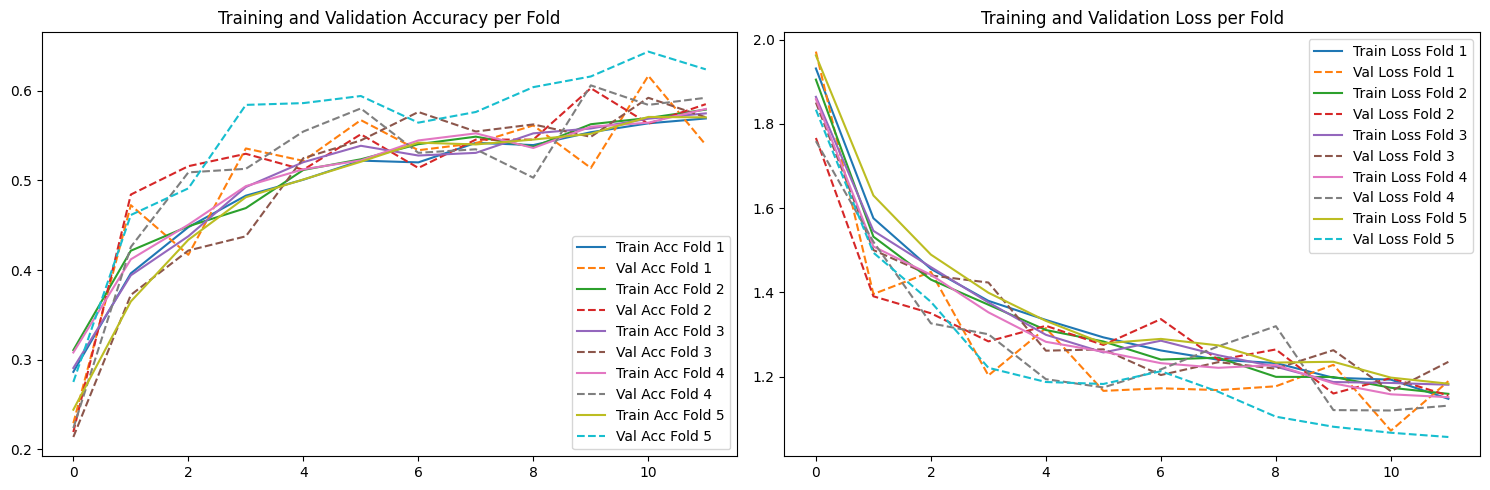

In [ ]:
avg_val_accuracy = np.mean([h.history['val_accuracy'][-1] for h in fold_histories])
avg_val_loss = np.mean([h.history['val_loss'][-1] for h in fold_histories])

print(f"\nAverage K-fold Validation Accuracy: {avg_val_accuracy:.4f}")
print(f"Average K-fold Validation Loss: {avg_val_loss:.4f}")

# Optional: Plotting individual fold histories
plt.figure(figsize=(15, 5))
for i, h in enumerate(fold_histories):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['accuracy'], label=f'Train Acc Fold {i+1}')
    plt.plot(h.history['val_accuracy'], label=f'Val Acc Fold {i+1}', linestyle='--')
    plt.subplot(1, 2, 2)
    plt.plot(h.history['loss'], label=f'Train Loss Fold {i+1}')
    plt.plot(h.history['val_loss'], label=f'Val Loss Fold {i+1}', linestyle='--')

plt.subplot(1, 2, 1)
plt.title('Training and Validation Accuracy per Fold')
plt.legend()
plt.subplot(1, 2, 2)
plt.title('Training and Validation Loss per Fold')
plt.legend()
plt.tight_layout()
plt.show()

## 3) Export fully-integer int8 `.tflite`

This produces:
- `models/custom_objects_int8.tflite`
- `models/custom_objects_labels.txt`


In [15]:
def representative_dataset(ds, num_batches=50):
    for x, _ in ds.take(num_batches):
        for i in range(x.shape[0]):
            yield [tf.expand_dims(x[i], 0)]


os.makedirs('models', exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = lambda: representative_dataset(train_ds)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter._experimental_disable_per_channel_quantization_for_dense_layers = True # fix for failure to allocate tensors error

tflite = converter.convert()
tflite_path = os.path.join('models', 'custom_objects_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite)

labels_path = os.path.join('models', 'custom_objects_labels.txt')
with open(labels_path, 'w', encoding='utf-8') as f:
    for n in class_names:
        f.write(n + '\n')

print('Wrote', tflite_path, 'bytes=', os.path.getsize(tflite_path))
print('Wrote', labels_path)
print('Class names:', class_names)


Saved artifact at '/tmp/tmppcnhsuzq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139508640044368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640044752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640044560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640044944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640045328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640045520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640046288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640042064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640042256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640046096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139508640048016:

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Wrote models/custom_objects_int8.tflite bytes= 162808
Wrote models/custom_objects_labels.txt
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4) Sanity-check the exported model

Before you deploy to hardware, verify that the exported `.tflite` runs and predicts something sensible.


In [16]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]
print('Input:', inp)
print('Output:', out)

# Take one batch from val_ds
xb, yb = next(iter(val_ds))
x0 = xb[0:1].numpy()
y0 = int(yb[0].numpy())

# Quantize input
scale, zp = inp['quantization']
xi = np.round(x0 / scale + zp).astype(np.int8)

interpreter.set_tensor(inp['index'], xi)
interpreter.invoke()
yo = interpreter.get_tensor(out['index'])[0]

# Dequantize output to view it as floats
oscale, ozp = out['quantization']
probs = (yo.astype(np.float32) - ozp) * oscale
pred = int(np.argmax(probs))

print('True:', class_names[y0], 'Pred:', class_names[pred])


Input: {'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 96, 96,  3], dtype=int32), 'shape_signature': array([-1, 96, 96,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output: {'name': 'StatefulPartitionedCall_1:0', 'index': 27, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
True: plastic Pred: trash


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
